Using backend: gpu

Available hardware:

gpu:0

gpu:1

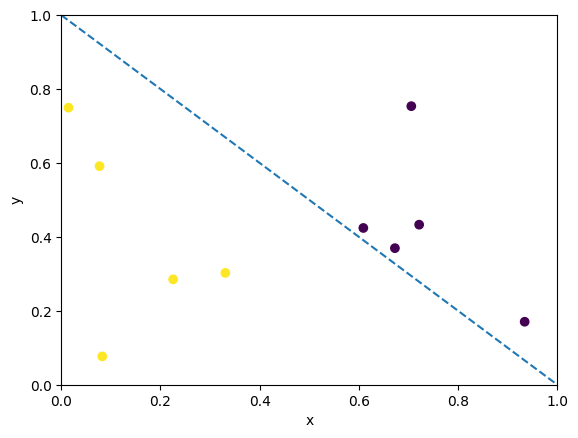

In [2]:
%run particle-insertion-modules.ipynb

In [ ]:
n_particles = 50

name = f"/data/stovey/architecture/architecture-study"
batch_size = 10
epochs = 1000

main(ds_size=n_particles, batch_size=batch_size, epochs=epochs, name=name)

In [3]:
@dataclass
class Measurement:
    width: int
    depth: int
    loss: np.ndarray
    trace: np.ndarray
    entropy: np.ndarray
    representations: np.ndarray
    loss_derivatives: np.ndarray
    class_entropy: dict

In [4]:
results = []

for particle_number in [20]:
    
    n_particles = particle_number
    name = f"{n_particles}-particle"
#     name = "study"
    
    experiment = np.load(f"{name}.npy", allow_pickle=True)[0]
    generator = Generator(n_samples=n_particles)

    trace = []
    entropy = []
    class_entropy = []
    loss = []
    representations = []
    loss_derivatives = []

    model = build_network(experiment.width, experiment.depth)()
    ntk_fn = get_ntk_function(model.apply, None)

    for i in track(range(0, len(experiment.parameters))):
        predictions = jax.nn.softmax(model.apply(
            {"params": experiment.parameters[i]}, generator.train_ds["inputs"]
        ))
        # Loss computation
        loss.append(
            ((predictions - generator.train_ds["targets"]) ** 2).sum(axis=-1).mean()
        )
        representations.append(
            predictions
        )
        loss_derivatives.append(
            compute_loss_derivative(
                predictions, generator.train_ds["targets"]
            )
        )

        # Compute the NTK
        ntk_matrix = ntk_fn(
                    generator.train_ds["inputs"],
                    generator.train_ds["inputs"],
                    {"params": experiment.parameters[i]}
                )

        # Trace computation
        trace.append(
            compute_trace(ntk_matrix)
        )

        # Entropy computation
        entropy.append(
            compute_entropy(ntk_matrix)
        )

        # Class entropy computation
#         class_entropy.append(
#             compute_class_entropy(generator.train_ds, ntk_matrix)
#         )
    results.append(
        Measurement(
            width=experiment.width,
            depth=experiment.depth,
            loss=np.array(loss),
            trace=np.array(trace),
            entropy=np.array(entropy),
            loss_derivatives=np.array(loss_derivatives),
            representations=np.array(representations),
            class_entropy=class_entropy
        )
    )
    
# np.save("experiment-analysis.npy", results)

Output()

In [5]:
# results = np.load("study.npy", allow_pickle=True)

In [6]:
results = results[0]

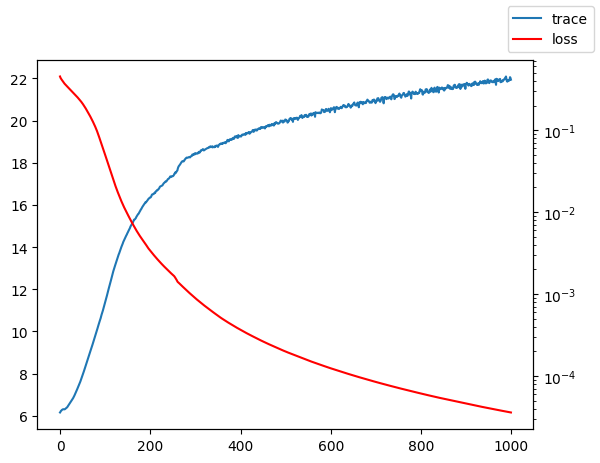

In [24]:
fig, ax = plt.subplots()
ax2 = ax.twinx()


ax.plot(np.sqrt(results.trace / 20), label="trace")
ax2.plot(results.loss, c="red", label="loss")
# ax2.plot(np.mean(results.loss_derivatives, axis=1), c="orange", label="dl / df")

ax2.set_yscale("log")

# plt.xlim(0, 500)
fig.legend()
plt.show()

In [8]:
loss_derivatives = np.mean(loss_derivatives, axis=1)

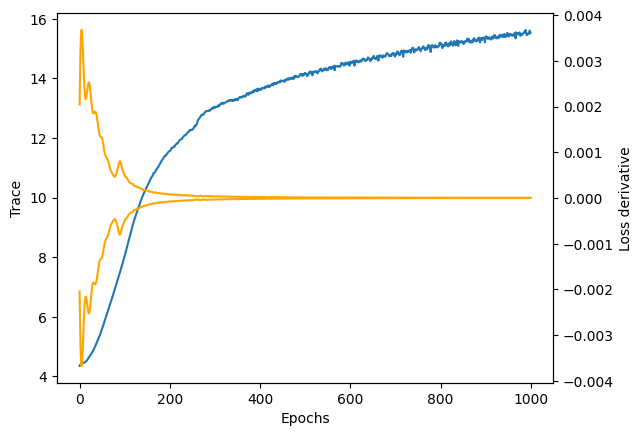

In [31]:
fig, ax = plt.subplots()
ax2 = ax.twinx()


ax.plot(np.sqrt(results.trace / 40))
# ax2.plot(results.loss, c="red")
ax2.plot(loss_derivatives, c="orange")

# ax2.set_yscale("log")

# plt.xlim(0, 100)
ax.set_xlabel("Epochs")
ax.set_ylabel("Trace")
ax2.set_ylabel("Loss derivative")
plt.show()

In [10]:
train_indices_one = np.where(generator.train_ds["targets"] == 0)[0]
train_indices_two = np.where(generator.train_ds["targets"] == 1)[0]

In [11]:
class_1 = np.take(np.array(results.representations), train_indices_one, axis=1)
class_2 = np.take(np.array(results.representations), train_indices_two, axis=1)

In [12]:
def compute_rg(trajectory):
    rg = []
    for frame in trajectory:
        mean_val = np.mean(frame)
        
        rg.append(
            np.mean((frame - mean_val) ** 2)
        )
        
    return rg

def compute_com_evolution(class_1, class_2):
    com_class_1 = np.mean(class_1, axis=1)
    com_class_2 = np.mean(class_2, axis=1)
    
    return abs(com_class_1 - com_class_2)

In [13]:
rg_one = compute_rg(class_1)
rg_two = compute_rg(class_2)
com_evolution = compute_com_evolution(class_1, class_2)

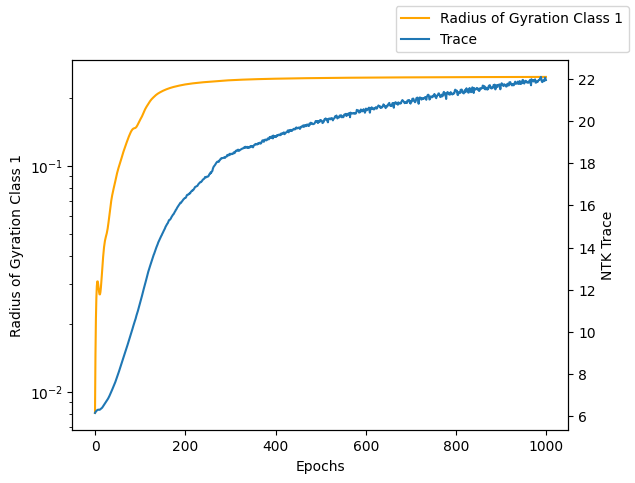

In [14]:
fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(rg_two, c="orange", label="Radius of Gyration Class 1")
ax2.plot(np.sqrt(results.trace / 20), label="Trace")
ax.set_yscale("log")


# plt.xlim(-50, 5000)

fig.legend()

ax.set_xlabel("Epochs")
ax.set_ylabel("Radius of Gyration Class 1")
ax2.set_ylabel("NTK Trace")
# plt.savefig("trace-to-rg.png")
plt.show()

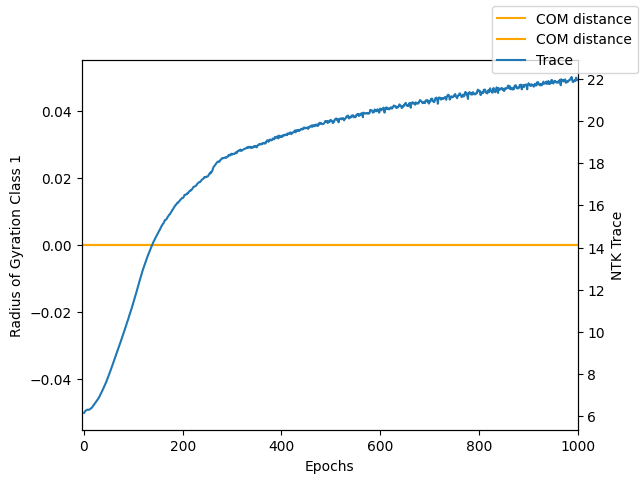

In [15]:
fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(com_evolution, c="orange", label="COM distance")
ax2.plot(np.sqrt(results.trace / 20), label="Trace")
# ax.set_yscale("log")


plt.xlim(-5, 1000)

fig.legend()

ax.set_xlabel("Epochs")
ax.set_ylabel("Radius of Gyration Class 1")
ax2.set_ylabel("NTK Trace")
# plt.savefig("trace-to-rg.png")
plt.show()